# 07 · Stance fingerprint & activist lead/lag

Two questions:

1. **Where does each subreddit sit?** A subreddit × stance heatmap and a ranked
   net-stance bar — the "fingerprint" of the conversation by community.
2. **Do activists move first?** The topical activist subs (`fuckcars`, `transit`,
   `urbanplanning`) carry a strong pro-transit selection bias. Does their stance
   shift *lead* the geographic subreddits around the launch?

In [1]:
import sys; sys.path.append(".")        # so config / analysis_utils import on Deepnote too
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
import analysis_utils as A
A.apply_style()
pd.set_option("display.width", 120)

In [2]:
sh = A.add_geo(A.load_rollup("stance_hourly"))
by_sub = A.stance_shares(
    sh.groupby(["subreddit","stance"], observed=True)["n"].sum().reset_index(),
    index_cols=["subreddit"])
by_sub = A.add_geo(by_sub)
by_sub = by_sub[by_sub.n_total >= C.MIN_N].sort_values("net")
lo, hi = A.net_ci(by_sub.share_pro, by_sub.share_anti, by_sub.n_total)
by_sub["net_lo"], by_sub["net_hi"] = lo, hi
by_sub[["subreddit","geo_tier","n_total","share_anti","share_pro","net"]].head(10)

stance,subreddit,geo_tier,n_total,share_anti,share_pro,net
3,Bushwick,Outer boroughs,316,0.642405,0.316456,-0.325949
36,nycbus,Transit / cycling,158,0.531646,0.335443,-0.196203
5,Flushing,Outer boroughs,98,0.571429,0.418367,-0.153061
40,statenisland,Outer boroughs,467,0.505353,0.355460,-0.149893
21,bronx,Outer boroughs,581,0.483649,0.344234,-0.139415
39,ridgewood,Outer boroughs,60,0.500000,0.366667,-0.133333
28,longisland,NY state / LI shed,3381,0.496303,0.364389,-0.131914
20,bergencounty,New Jersey shed,333,0.477477,0.348348,-0.129129
42,uppereastside,Manhattan core,305,0.426230,0.324590,-0.101639
15,Queens,Outer boroughs,1261,0.413164,0.341792,-0.071372


### Stance fingerprint heatmap (subreddits sorted by net stance)

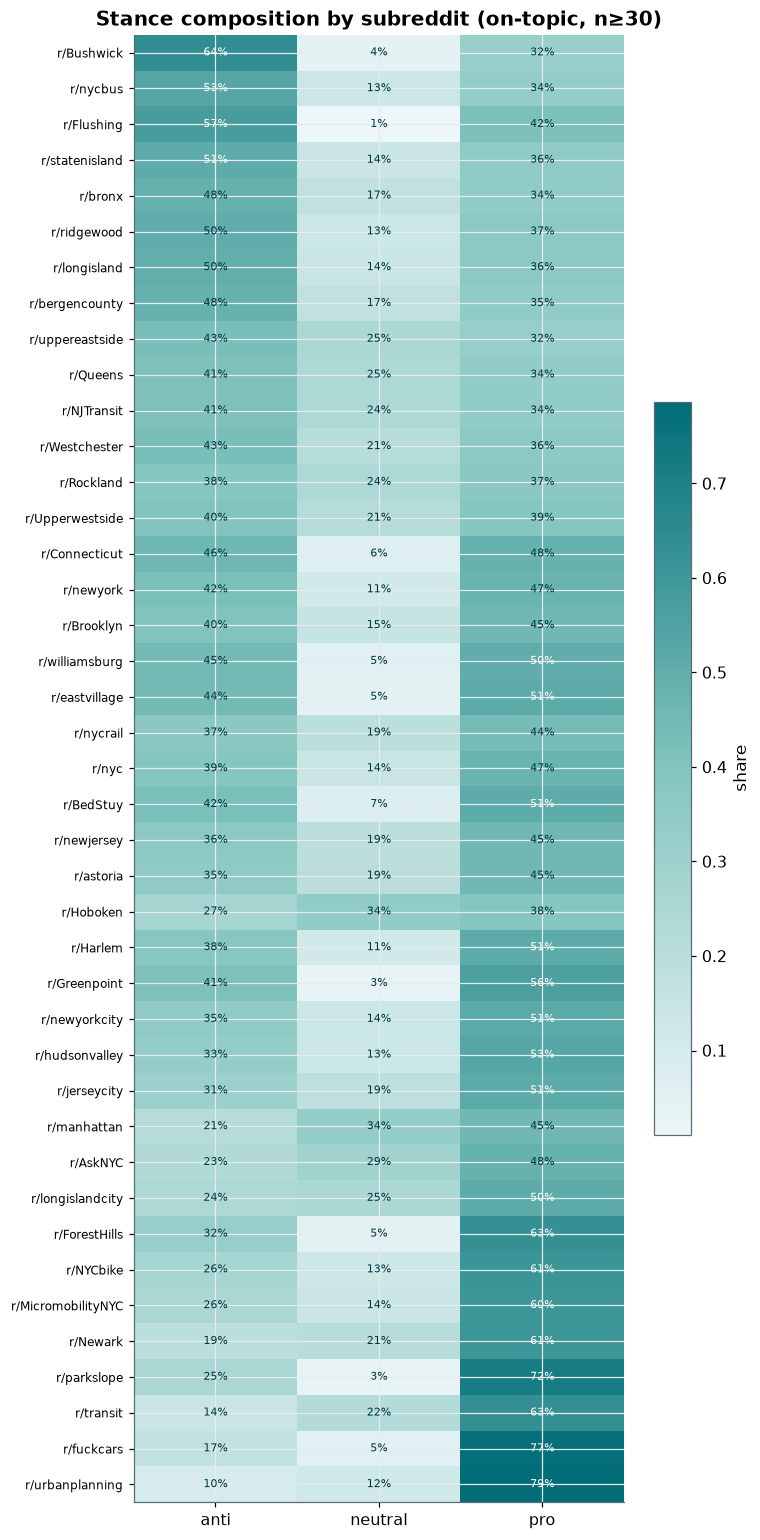

In [3]:
hm = by_sub.set_index("subreddit")[["share_anti","share_neutral","share_pro"]]
fig, ax = plt.subplots(figsize=(7, 0.32*len(hm)+1))
im = ax.imshow(hm.values, aspect="auto", cmap=plt.cm.colors.LinearSegmentedColormap.from_list(
        "team", [C.PALETTE["pale"], C.PALETTE["teal"], C.PALETTE["deep_teal"]]))
ax.set_xticks(range(3)); ax.set_xticklabels(["anti","neutral","pro"])
ax.set_yticks(range(len(hm))); ax.set_yticklabels([f"r/{s}" for s in hm.index], fontsize=8)
for i in range(len(hm)):
    for j in range(3):
        ax.text(j, i, f"{hm.values[i,j]:.0%}", ha="center", va="center", fontsize=7,
                color="white" if hm.values[i,j]>0.5 else "#003840")
ax.set_title("Stance composition by subreddit (on-topic, n≥%d)" % C.MIN_N)
fig.colorbar(im, ax=ax, shrink=0.5, label="share")
plt.tight_layout(); plt.show()

### Ranked net stance with CIs, colored by tier

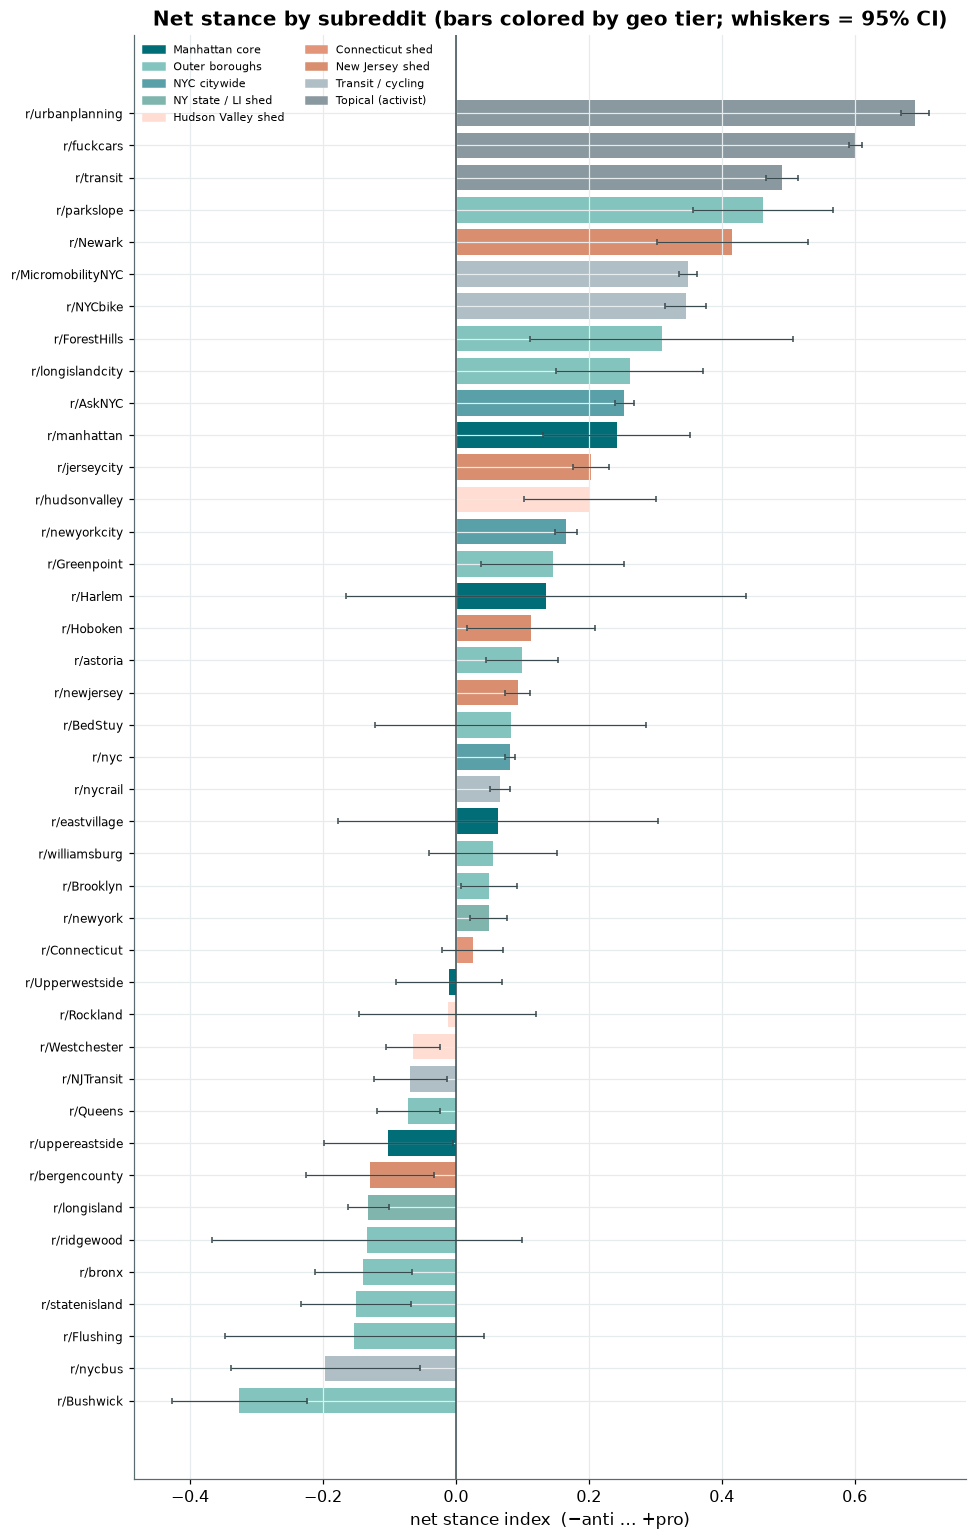

In [4]:
tier_color = dict(zip(C.GEO_TIER_ORDER, [C.PALETTE["deep_teal"],C.PALETTE["teal"],"#5AA0A8",
        "#7FB5AD",C.PALETTE["pink"],C.PALETTE["terracotta"],"#D98E6F","#B0BEC5","#8A99A0"]))
r = by_sub.sort_values("net"); y = np.arange(len(r))
fig, ax = plt.subplots(figsize=(9, 0.32*len(r)+1))
ax.barh(y, r.net, color=[tier_color.get(t,"#999") for t in r.geo_tier])
ax.errorbar(r.net, y, xerr=[r.net-r.net_lo, r.net_hi-r.net], fmt="none", ecolor="#3A4B4F", elinewidth=0.8, capsize=2)
ax.axvline(0, color="#3A4B4F", lw=1)
ax.set_yticks(y); ax.set_yticklabels([f"r/{s}" for s in r.subreddit], fontsize=8)
ax.set_xlabel("net stance index  (−anti … +pro)")
ax.set_title("Net stance by subreddit (bars colored by geo tier; whiskers = 95% CI)")
handles=[plt.Rectangle((0,0),1,1,color=tier_color[t]) for t in C.GEO_TIER_ORDER if t in r.geo_tier.unique()]
ax.legend(handles,[t for t in C.GEO_TIER_ORDER if t in r.geo_tier.unique()], fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### Activist vs geographic: does activist stance lead?

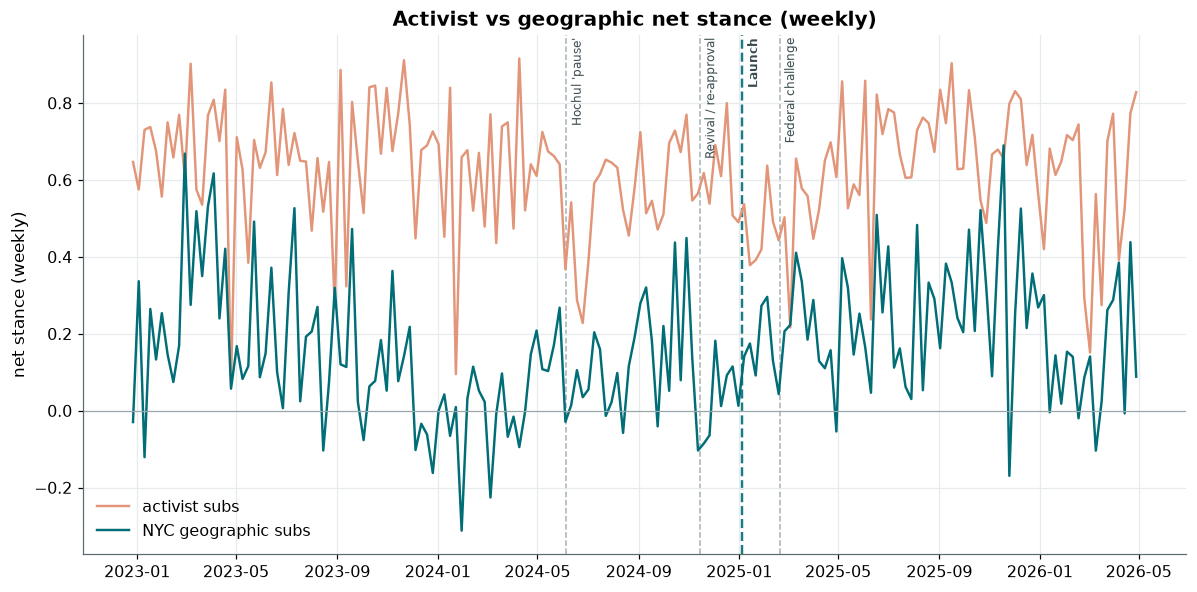

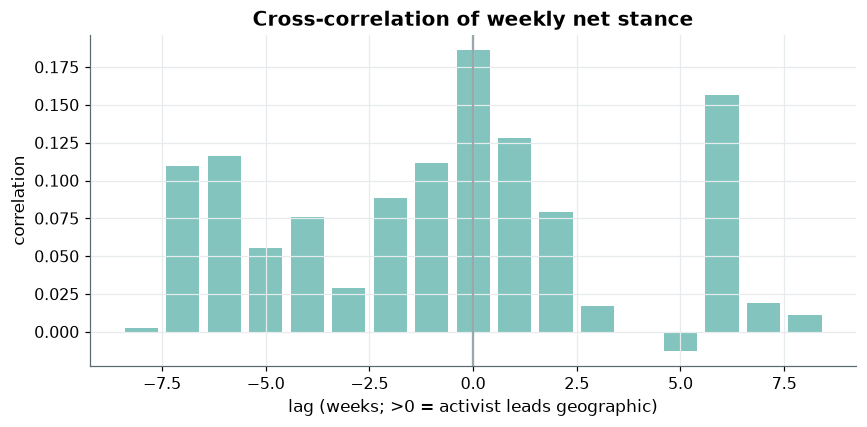

Peak correlation at lag: 0 weeks


In [5]:
sh["grp"] = np.where(sh.is_topical==True, "activist",
             np.where(sh.geo_tier.isin(["Manhattan core","Outer boroughs","NYC citywide"]), "NYC-geographic", "other"))
g = sh[sh.grp.isin(["activist","NYC-geographic"])]
agg = A.aggregate(g, "weekly", by=("grp",), stance_col="stance")
wide = A.stance_shares(agg, index_cols=["period","grp"]).sort_values("period")
piv = wide.pivot(index="period", columns="grp", values="net").dropna()
fig, ax = plt.subplots()
ax.plot(piv.index, piv["activist"], color=C.PALETTE["terracotta"], lw=1.6, label="activist subs")
ax.plot(piv.index, piv["NYC-geographic"], color=C.PALETTE["deep_teal"], lw=1.6, label="NYC geographic subs")
ax.axhline(0, color="#9AA7AB", lw=0.8); ax.set_ylabel("net stance (weekly)")
ax.set_title("Activist vs geographic net stance (weekly)"); ax.legend(); A.annotate_events(ax)
plt.tight_layout(); plt.show()

# Cross-correlation: does activist lead geographic? (positive lag = activist leads)
a = piv["activist"] - piv["activist"].mean()
b = piv["NYC-geographic"] - piv["NYC-geographic"].mean()
lags = range(-8,9)
cc = [np.corrcoef(a.shift(L).dropna().align(b, join="inner")[0], a.shift(L).dropna().align(b, join="inner")[1])[0,1] if False else None for L in lags]
# simpler robust cross-correlation
vals=[]
for L in lags:
    s = pd.concat([a.shift(L), b], axis=1).dropna()
    vals.append(s.iloc[:,0].corr(s.iloc[:,1]))
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(list(lags), vals, color=C.PALETTE["teal"])
ax.axvline(0, color="#9AA7AB"); ax.set_xlabel("lag (weeks; >0 = activist leads geographic)")
ax.set_ylabel("correlation"); ax.set_title("Cross-correlation of weekly net stance")
plt.tight_layout(); plt.show()
print("Peak correlation at lag:", list(lags)[int(np.nanargmax(vals))], "weeks")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>